# Experiment 7: Model Validation, Hyperparameter Optimization and Pipelines

## Aim

To understand and implement model validation techniques, hyperparameter optimization methods, and machine learning pipelines for building reliable and efficient machine learning models.

## 1. Model Validation

Model validation is the process of evaluating how well a machine learning model performs on unseen data. It helps determine whether a model can generalize effectively to new observations rather than simply memorizing the training data.

### 1.1 Train-Test Split / Holdout Validation

In the train-test split method, the dataset is divided into two independent subsets:

* **Training set:** Used to train the machine learning model.
* **Testing set:** Used to evaluate the trained model on unseen data.

For example, an **80:20 split** uses 80% of the data for training and 20% for testing.

In classification problems, **stratified train-test splitting** can be used to preserve approximately the same class distribution in both training and testing sets.

**Advantages:**

* Simple and computationally efficient.
* Easy to implement.
* Suitable for large datasets.

**Limitations:**

* Model performance depends on the particular train-test split.
* A single split may not provide a reliable estimate when the dataset is small.

### 1.2 K-Fold Cross-Validation

K-Fold Cross-Validation is a resampling technique used to obtain a more reliable estimate of model performance.

The dataset is divided into **K approximately equal-sized folds**. The model is trained and tested K times. During each iteration:

1. One fold is used as the validation/test fold.
2. The remaining K−1 folds are used for training.
3. The process is repeated until every fold has been used for validation.
4. The performance scores from all folds are averaged.

For example, in **10-Fold Cross-Validation**, the dataset is divided into 10 folds and the model is trained and evaluated 10 times.

The mean cross-validation score is calculated as:

**Mean CV Score = (Score₁ + Score₂ + ... + Scoreₖ) / K**

The standard deviation of the scores indicates the variation in model performance across different folds.

### 1.3 Stratified K-Fold Cross-Validation

Stratified K-Fold Cross-Validation is mainly used for classification problems. It ensures that each fold approximately maintains the same proportion of classes as the original dataset.

For example, if the original dataset contains 65% samples of Class 0 and 35% samples of Class 1, stratified cross-validation attempts to maintain approximately the same distribution in every fold.

This is particularly useful when the classes are imbalanced.

### 1.4 Holdout Validation vs. Cross-Validation

Holdout validation is faster and simpler, but its result can depend strongly on the selected train-test split.

Cross-validation requires more computation because the model is trained multiple times, but it provides multiple validation scores and therefore gives a better indication of the variability and stability of model performance.

---

## 2. Hyperparameter Optimization

**Hyperparameters** are model settings that are specified before the training process begins. They are not directly learned from the training data.

Examples include:

* Learning rate
* Number of trees
* Maximum tree depth
* SVM parameter **C**
* SVM **gamma**
* Kernel type
* Number of neighbors in KNN

Choosing suitable hyperparameters can significantly affect model performance.

**Hyperparameter optimization** is the process of systematically searching for a suitable combination of hyperparameter values that produces good model performance.

### 2.1 Grid Search

**Grid Search** evaluates every possible combination of hyperparameter values specified in a parameter grid.

For example, if we define:

* C = {0.1, 1, 10, 100}
* Gamma = {0.01, 0.1, 1}
* Kernel = {linear, RBF}

Grid Search evaluates all possible combinations of these values using cross-validation.

The combination producing the best validation performance is selected as the optimal configuration.

**Advantages:**

* Systematic and easy to understand.
* Searches the complete specified parameter grid.
* Useful when the search space is relatively small.

**Limitation:**

* Can become computationally expensive when many hyperparameters and values are included.

### 2.2 Randomized Search

**Randomized Search** randomly selects a specified number of hyperparameter combinations from the given parameter distributions.

Instead of testing every possible combination, only a fixed number of randomly selected combinations are evaluated.

For example, `n_iter = 10` means that 10 randomly selected parameter combinations are evaluated.

**Advantages:**

* Usually requires less computation than exhaustive Grid Search.
* Suitable for large hyperparameter spaces.
* Can explore a wider range of values with a fixed computational budget.

**Limitation:**

* It may not evaluate the best combination if the number of random trials is too small.

### 2.3 Grid Search vs. Randomized Search

| Feature                | Grid Search                | Randomized Search            |
| ---------------------- | -------------------------- | ---------------------------- |
| Search method          | Exhaustive                 | Random sampling              |
| Number of combinations | All specified combinations | Fixed number of combinations |
| Computational cost     | Can be high                | Usually lower                |
| Search coverage        | Complete specified grid    | Partial/random               |
| Suitable for           | Small search spaces        | Large search spaces          |

---

## 3. Machine Learning Pipelines

A **machine learning pipeline** is a sequence of processing steps that are executed in a predefined order.

A typical machine learning workflow may contain:

**Data → Preprocessing → Feature Transformation → Model Training → Prediction**

For example:

**StandardScaler → PCA → Classifier**

A pipeline combines these operations into a single workflow.

### 3.1 Importance of Pipelines

Pipelines help organize machine learning workflows and reduce errors by ensuring that preprocessing and model training are performed consistently.

They are especially useful when applying cross-validation and hyperparameter optimization because preprocessing operations can be performed separately within each training fold.

### 3.2 Common Pipeline Steps

Common preprocessing and modeling steps include:

* Missing-value imputation
* Feature scaling
* Encoding categorical variables
* Feature selection
* Dimensionality reduction such as PCA
* Machine learning classification or regression

For example:

**StandardScaler → PCA → SVM**

Here:

1. **StandardScaler** standardizes the input features.
2. **PCA** reduces the dimensionality of the feature space.
3. **SVM** performs the final classification.

### 3.3 Advantages of Machine Learning Pipelines

* Provides an organized workflow.
* Ensures consistent preprocessing.
* Reduces data leakage during cross-validation.
* Makes model training and evaluation easier.
* Allows preprocessing and model parameters to be optimized together.
* Makes the complete workflow easier to reproduce.

---

## 4. Important Concepts

### Data Leakage

Data leakage occurs when information from outside the training data is unintentionally used during model training. It can lead to overly optimistic performance estimates.

For example, fitting a feature scaler on the complete dataset before cross-validation can allow information from validation folds to influence the training process.

Using a pipeline helps prevent this type of leakage by fitting preprocessing steps separately within each training fold.

### Model Generalization

Generalization refers to the ability of a trained model to perform well on previously unseen data.

A good validation strategy provides a better estimate of how the model may perform on new observations.

### Overfitting

Overfitting occurs when a model learns the training data too closely, including noise and specific patterns that do not generalize to new data.

A model may have very good training performance but poor validation or test performance.

### Underfitting

Underfitting occurs when a model is too simple to capture the important patterns in the data. It generally results in poor performance on both training and unseen data.

---

## 5. Evaluation of Validation and Optimization

Model validation techniques provide estimates of model performance, while hyperparameter optimization attempts to identify suitable model configurations.

A typical workflow is:

**Dataset → Train/Test Split → Preprocessing → Cross-Validation → Hyperparameter Search → Best Model → Test Evaluation**

The final test set should be kept separate from the hyperparameter optimization process so that it provides an unbiased evaluation of the selected model.

## Conclusion

Model validation, hyperparameter optimization, and pipelines are important components of a reliable machine learning workflow. Train-test split provides a simple holdout evaluation, while K-Fold and Stratified K-Fold Cross-Validation provide repeated estimates of model performance. Grid Search and Randomized Search help identify suitable hyperparameter configurations. Machine learning pipelines combine preprocessing and modeling steps into a consistent workflow and help reduce the possibility of data leakage during model validation.


## Task 1: Implement train-test split and k-fold cross-validation techniques for model validation
*Suggested Dataset: Pima Indians Diabetes Dataset*


### Subtask 1.1: Data Acquisition and Class Target Inspections
**Concept:** Import warnings suppression and libraries, load the raw Pima Indians Diabetes dataset, and inspect its basic target outcome distribution.


In [ ]:
import warnings


In [ ]:
warnings.filterwarnings("ignore")


In [ ]:
import pandas as pd


In [ ]:
import numpy as np


In [ ]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"


In [ ]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)


In [ ]:
X_pima = pima_df[pima_cols[:-1]]


In [ ]:
y_pima = pima_df['Outcome']


In [ ]:
print("Pima Dataset Shape (rows, cols):", pima_df.shape)


Pima Dataset Shape (rows, cols): (768, 9)


In [ ]:
print("\nClass Outcome Distribution:")



Class Outcome Distribution:


In [ ]:
print(pima_df['Outcome'].value_counts())


Outcome
0    500
1    268
Name: count, dtype: int64


### Subtask 1.2: Implementing Holdout Validation (Stratified Train-Test Split)
**Concept:** Implement a Stratified Train-Test Split (80% train, 20% test) to establish a baseline holdout validation strategy, and evaluate a baseline Random Forest model.


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)


In [ ]:
rf_baseline = RandomForestClassifier(random_state=42)


In [ ]:
rf_baseline.fit(X_train_p, y_train_p)


RandomForestClassifier(random_state=42)

In [ ]:
holdout_preds = rf_baseline.predict(X_test_p)


In [ ]:
holdout_accuracy = accuracy_score(y_test_p, holdout_preds)


In [ ]:
print(f"Stratified Holdout (Train-Test Split) Accuracy: {holdout_accuracy * 100:.2f}%")


Stratified Holdout (Train-Test Split) Accuracy: 75.97%


### Subtask 1.3: Implementing K-Fold Cross-Validation (K=10)
**Concept:** Perform robust 10-fold Stratified K-Fold Cross-Validation across the entire feature space to compute a more reliable, generalizable accuracy score.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [ ]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


In [ ]:
cv_scores = cross_val_score(rf_baseline, X_pima, y_pima, cv=cv_strategy, scoring='accuracy')


In [ ]:
print("10-Fold Stratified CV Accuracy Scores:")


10-Fold Stratified CV Accuracy Scores:


In [ ]:
print(cv_scores.round(4))


[0.8052 0.7532 0.7143 0.8701 0.7922 0.7273 0.7532 0.7662 0.7895 0.7237]


In [ ]:
print(f"\nMean Cross-Validation Accuracy Score: {cv_scores.mean() * 100:.2f}%")



Mean Cross-Validation Accuracy Score: 76.95%


In [ ]:
print(f"Standard Deviation of CV Accuracy:     {cv_scores.std() * 100:.2f}%")


Standard Deviation of CV Accuracy:     4.45%


### Subtask 1.4: Visualizing Cross-Validation Score Variance
**Concept:** Plot a boxplot of your cross-validation fold scores to analyze model variance and score stability across folds.


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import seaborn as sns


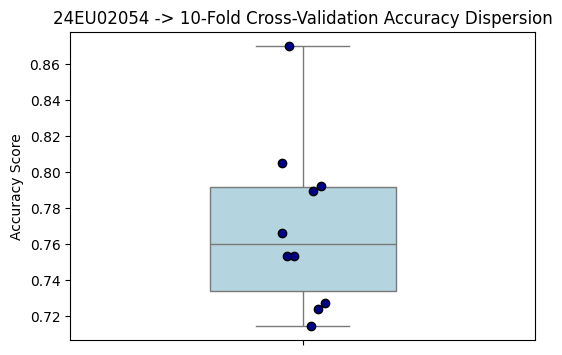

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=cv_scores, color='lightblue', width=0.4)
sns.stripplot(y=cv_scores, color='darkblue', size=6, jitter=0.05, edgecolor='black', linewidth=1)
plt.title("24EU02054 -> C10-Fold Cross-Validation Accuracy Dispersion")
plt.ylabel("Accuracy Score")
plt.show()


### Subtask 1.5: Evaluating Validation Strategy Trade-offs
**Concept:** Compare holdout validation accuracy against the mean cross-validation accuracy, and analyze their trade-offs.


In [ ]:
validation_comparison = pd.DataFrame({
    'Validation Strategy': ['Holdout Stratified (80/20 Split)', '10-Fold Stratified Cross-Validation (Mean)'],
    'Accuracy Score (%)': [holdout_accuracy * 100, cv_scores.mean() * 100],
    'Score Std Deviation (%)': [0.0, cv_scores.std() * 100]
})


In [ ]:
print("--- Validation Strategy Trade-offs ---")


--- Validation Strategy Trade-offs ---


In [ ]:
print(validation_comparison.to_string(index=False))


                       Validation Strategy  Accuracy Score (%)  Score Std Deviation (%)
          Holdout Stratified (80/20 Split)           75.974026                 0.000000
10-Fold Stratified Cross-Validation (Mean)           76.949761                 4.448026


## Task 2: Perform hyperparameter optimization using Grid Search and compare optimized model performance
*Suggested Dataset: Sonar Dataset*


### Subtask 2.1: Standard Scaling and High-Dimensional Target Split
**Concept:** Import warnings suppression, load the Sonar dataset, map targets to binary labels, standardize features, and perform a stratified split.


In [ ]:
import warnings


In [ ]:
warnings.filterwarnings("ignore")


In [ ]:
import pandas as pd


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"


In [ ]:
sonar_features = [f"F_{i}" for i in range(1, 61)]


In [ ]:
sonar_columns = sonar_features + ['Class']


In [ ]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)


In [ ]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})


In [ ]:
X_sonar = sonar_df[sonar_features]


In [ ]:
y_sonar = sonar_df['Class_numeric']


In [ ]:
scaler_sonar = StandardScaler()


In [ ]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)


In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)


In [ ]:
print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [ ]:
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Test Set Shape: (63, 60)


### Subtask 2.2: Establishing a Baseline Default SVM Classifier
**Concept:** Train a Support Vector Machine (SVM) classifier with default hyperparameters and evaluate its baseline accuracy on the test set.


In [ ]:
from sklearn.svm import SVC


In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
svm_default = SVC(probability=True, random_state=42)


In [ ]:
svm_default.fit(X_train_s, y_train_s)


SVC(probability=True, random_state=42)

In [ ]:
default_preds = svm_default.predict(X_test_s)


In [ ]:
default_accuracy = accuracy_score(y_test_s, default_preds)


In [ ]:
print(f"Default SVM Test Accuracy: {default_accuracy * 100:.2f}%")


Default SVM Test Accuracy: 84.13%


### Subtask 2.3: Implementing Hyperparameter Tuning with Grid Search (GridSearchCV)
**Concept:** Perform Grid Search cross-validation over a parameter grid (C, gamma, kernel) to find the model configuration with the highest accuracy.


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}


In [ ]:
grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


In [ ]:
grid_search.fit(X_train_s, y_train_s)


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [ ]:
best_svm_grid = grid_search.best_estimator_


In [ ]:
grid_preds = best_svm_grid.predict(X_test_s)


In [ ]:
grid_accuracy = accuracy_score(y_test_s, grid_preds)


In [ ]:
print("Optimal Hyperparameters Selected via Grid Search:", grid_search.best_params_)


Optimal Hyperparameters Selected via Grid Search: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [ ]:
print(f"Grid-Search Optimized SVM Test Accuracy: {grid_accuracy * 100:.2f}%")


Grid-Search Optimized SVM Test Accuracy: 92.06%


### Subtask 2.4: Implementing Hyperparameter Tuning with Randomized Search (RandomizedSearchCV)
**Concept:** Perform Randomized Search cross-validation over the same parameter space to compare its execution speed and model accuracy against Grid Search.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
param_distributions = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf']
}


In [ ]:
random_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)


In [ ]:
random_search.fit(X_train_s, y_train_s)


RandomizedSearchCV(cv=5, estimator=SVC(probability=True, random_state=42),
                   n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'gamma': ['scale', 'auto', 0.01, 0.1,
                                                  1],
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='accuracy')

In [ ]:
best_svm_random = random_search.best_estimator_


In [ ]:
random_preds = best_svm_random.predict(X_test_s)


In [ ]:
random_accuracy = accuracy_score(y_test_s, random_preds)


In [ ]:
print("Optimal Hyperparameters Selected via Randomized Search:", random_search.best_params_)


Optimal Hyperparameters Selected via Randomized Search: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}


In [ ]:
print(f"Randomized-Search Optimized SVM Test Accuracy: {random_accuracy * 100:.2f}%")


Randomized-Search Optimized SVM Test Accuracy: 79.37%


### Subtask 2.5: Performance Comparison: Default vs. Grid-Search vs. Randomized-Search
**Concept:** Tabulate and plot a bar chart comparing test accuracies across Default, Grid-Search, and Randomized-Search models.


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import seaborn as sns


In [ ]:
optimization_results = pd.DataFrame({
    'Tuning Strategy': ['Default Parameters SVM', 'Grid-Search Optimized SVM', 'Randomized-Search Optimized SVM'],
    'Test Accuracy (%)': [default_accuracy * 100, grid_accuracy * 100, random_accuracy * 100]
})


In [ ]:
print("--- Hyperparameter Optimization Comparison ---")


--- Hyperparameter Optimization Comparison ---


In [ ]:
print(optimization_results.to_string(index=False))


                Tuning Strategy  Test Accuracy (%)
         Default Parameters SVM          84.126984
      Grid-Search Optimized SVM          92.063492
Randomized-Search Optimized SVM          79.365079


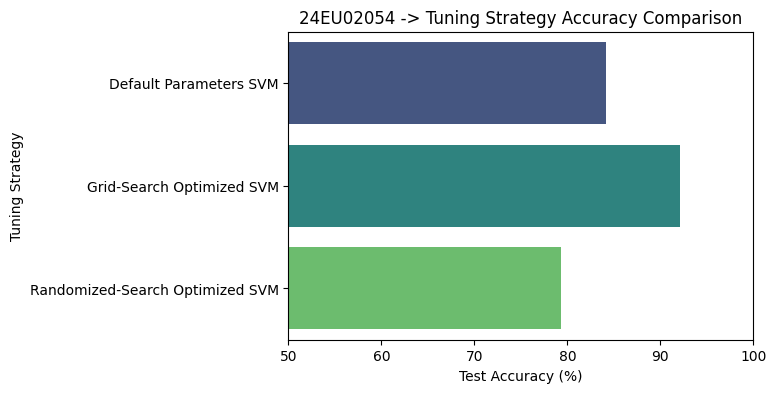

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=optimization_results, x='Test Accuracy (%)', y='Tuning Strategy', palette='viridis')
plt.xlim([50, 100])
plt.title("24EU02054 -> Tuning Strategy Accuracy Comparison")
plt.show()


## Task 3: Develop machine learning pipelines for preprocessing, training, and evaluation of predictive models
*Dataset Utilized: Pima Indians Diabetes Dataset (Bundling Imputation, Scaling, and SVC Model)*


### Subtask 3.1: Constructing the End-to-End Machine Learning Pipeline
**Concept:** Construct a pipeline that bundles missing value imputation (replacing invalid zeros with median values) and standard scaling together with a Support Vector Classifier (SVC).


In [ ]:
import warnings


In [ ]:
warnings.filterwarnings("ignore")


In [ ]:
import pandas as pd


In [ ]:
import numpy as np


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
from sklearn.pipeline import Pipeline


In [ ]:
from sklearn.impute import SimpleImputer


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
from sklearn.svm import SVC


In [ ]:
pima_raw_df = pd.read_csv(pima_url, header=None, names=pima_cols)


In [ ]:
X_raw_p = pima_raw_df[pima_cols[:-1]].copy()


In [ ]:
y_raw_p = pima_raw_df['Outcome']


In [ ]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [ ]:
X_raw_p[cols_to_impute] = X_raw_p[cols_to_impute].replace(0, np.nan)


In [ ]:
X_train_raw_p, X_test_raw_p, y_train_raw_p, y_test_raw_p = train_test_split(
    X_raw_p, y_raw_p, test_size=0.20, stratify=y_raw_p, random_state=42
)


In [ ]:
ml_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SVC(probability=True, class_weight='balanced', random_state=42))
])


In [ ]:
print("Cost-sensitive balanced Pipeline constructed successfully.")


Cost-sensitive balanced Pipeline constructed successfully.


### Subtask 3.2: Tuning the Pipeline with Grid Search
**Concept:** Configure a GridSearchCV parameter grid using double-underscore syntax to tune imputation, scaling, and classification parameters simultaneously while preventing data leakage.


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
pipeline_param_grid = {
    'imputer__strategy': ['mean', 'median'],
    'classifier__C': [0.1, 1, 5, 10, 50],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
}


In [ ]:
pipeline_cv = GridSearchCV(estimator=ml_pipeline, param_grid=pipeline_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)


In [ ]:
pipeline_cv.fit(X_train_raw_p, y_train_raw_p)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('classifier',
                                        SVC(class_weight='balanced',
                                            probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.1, 1, 5, 10, 50],
                         'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
                         'imputer__strategy': ['mean', 'median']},
             scoring='f1_weighted')

In [ ]:
best_pipeline = pipeline_cv.best_estimator_


In [ ]:
print("Optimal Pipeline Hyperparameters Selected:")


Optimal Pipeline Hyperparameters Selected:


In [ ]:
print(pipeline_cv.best_params_)


{'classifier__C': 1, 'classifier__gamma': 0.01, 'imputer__strategy': 'median'}


### Subtask 3.3: Evaluating the Tuned Pipeline on Raw Test Data
**Concept:** Predict on the raw, unprocessed test data using the tuned pipeline, and evaluate its performance using accuracy, a confusion matrix, and a classification report.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
import seaborn as sns


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
pipeline_preds = best_pipeline.predict(X_test_raw_p)


In [ ]:
pipeline_accuracy = accuracy_score(y_test_raw_p, pipeline_preds)


In [ ]:
print(f"End-to-End Pipeline Test Accuracy: {pipeline_accuracy * 100:.2f}%\\n")


End-to-End Pipeline Test Accuracy: 74.03%\n


In [ ]:
print("--- Classification Report (Observe the improved Class 1 metrics) ---")


--- Classification Report (Observe the improved Class 1 metrics) ---


In [ ]:
print(classification_report(y_test_raw_p, pipeline_preds))


              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



In [ ]:
cm_pipeline = confusion_matrix(y_test_raw_p, pipeline_preds)


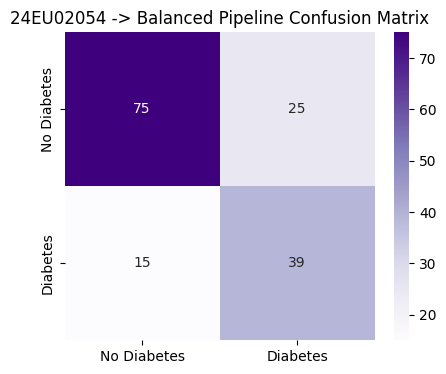

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pipeline, annot=True, fmt='d', cmap='Purples', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("24EU02054 -> Balanced Pipeline Confusion Matrix")
plt.show()


### Subtask 3.4: Serializing the Trained Pipeline to Disk
**Concept:** Serialize and save your optimized end-to-end pipeline model to disk using the joblib library.


In [ ]:
import joblib


In [ ]:
saved_filename = "pima_diabetes_pipeline.joblib"


In [ ]:
joblib.dump(best_pipeline, saved_filename)


['pima_diabetes_pipeline.joblib']

In [ ]:
print(f"End-to-End Pipeline successfully serialized and saved to '{saved_filename}'.")


End-to-End Pipeline successfully serialized and saved to 'pima_diabetes_pipeline.joblib'.


### Subtask 3.5: Deploying and Validating the Saved Pipeline
**Concept:** Load your saved pipeline model back from disk and verify its functionality by predicting class labels on unprocessed mock input data.


In [ ]:
deployed_pipeline = joblib.load(saved_filename)


In [ ]:
raw_patient_record = pd.DataFrame([{
    'Pregnancies': 1,
    'Glucose': 189,
    'BloodPressure': 60,
    'SkinThickness': 0,
    'Insulin': 0,
    'BMI': 30.1,
    'DiabetesPedigreeFunction': 0.398,
    'Age': 59
}])


In [ ]:
raw_patient_record[cols_to_impute] = raw_patient_record[cols_to_impute].replace(0, np.nan)


In [ ]:
deployed_pred = deployed_pipeline.predict(raw_patient_record)


In [ ]:
deployed_probs = deployed_pipeline.predict_proba(raw_patient_record)


In [ ]:
print("Deployed Pipeline Prediction Output:")


Deployed Pipeline Prediction Output:


In [ ]:
print("Predicted Class Label (0 = No Diabetes, 1 = Diabetes):", deployed_pred[0])


Predicted Class Label (0 = No Diabetes, 1 = Diabetes): 1


In [ ]:
print(f"Probability of Diabetes Class: {deployed_probs[0][1]*100:.2f}%")


Probability of Diabetes Class: 77.00%
